In [1]:
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp

In [3]:
from scripts.figures import set_rc_parameters

In [4]:
# Enable double precision
jax.config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

### Testing MC integration with Metropolis and sampling uniformly over $[a,b]$

Monte Carlo Integral Estimate: 0.9919


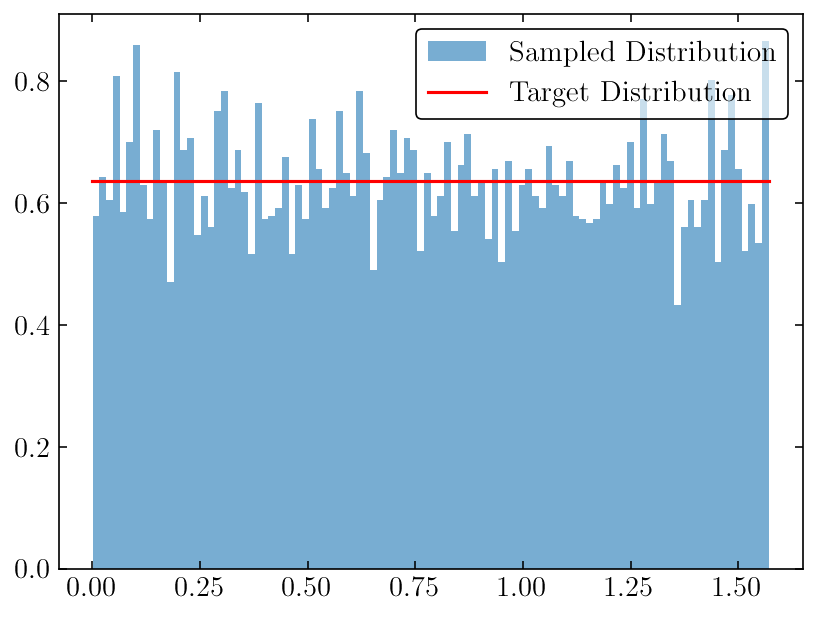

In [7]:
key = jax.random.PRNGKey(0)
a, b = 0, jnp.pi / 2  # Interval boundaries
num_samples = 10000

def f(x):
    return jnp.sin(x)  # Example function to integrate

def target_distribution(x):
    # Uniform distribution over [a, b]
    return jnp.where((x >= a) & (x <= b), 1 / (b - a), 0)

def metropolis_integration(key, num_samples, a, b):
    samples = []
    x_current = a + (b - a) * jax.random.uniform(key)  # Initial point
    key, subkey = jax.random.split(key)
    
    for _ in range(num_samples):
        key, subkey = jax.random.split(key)
        x_proposal = x_current + jax.random.normal(subkey) * 0.5  # Proposal step
        
        # Acceptance probability
        acceptance_ratio = target_distribution(x_proposal) / target_distribution(x_current)
        acceptance_prob = jnp.minimum(1.0, acceptance_ratio)

        key, subkey = jax.random.split(key)
        if jax.random.uniform(subkey) < acceptance_prob:
            x_current = x_proposal

        # Store sample if within bounds
        if a <= x_current <= b:
            samples.append(x_current)

    return jnp.array(samples)

samples = metropolis_integration(key, num_samples, a, b)
integral_estimate = (b - a) * jnp.mean(f(samples))

print(f"Monte Carlo Integral Estimate: {integral_estimate:.4f}")

# Plotting
plt.hist(samples, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 100)
plt.plot(x, target_distribution(x), label="Target Distribution", color='red')
plt.legend()
plt.show()